In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#  Charger les données
data = pd.read_csv('Salary_Data.csv')

data

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891
5,2.9,56642
6,3.0,60150
7,3.2,54445
8,3.2,64445
9,3.7,57189


In [4]:
# Variables
X = data[['YearsExperience']].values
y = data['Salary'].values

In [5]:
# 3️⃣ Fonction polynomiale (équivalent de PolynomialFeatures)
def polynomial_features(X, degree):
    X_poly = np.ones((X.shape[0], 1))  # biais
    for d in range(1, degree + 1):
        X_poly = np.hstack((X_poly, X**d))
    return X_poly

degree = 2
X_poly = polynomial_features(X, degree)

In [6]:
# 4️⃣ Train / Test
np.random.seed(0)
indices = np.arange(len(X_poly))
np.random.shuffle(indices)

train_size = int(2/3 * len(indices))
train_idx = indices[:train_size]
test_idx = indices[train_size:]

X_train = X_poly[train_idx]
X_test  = X_poly[test_idx]
y_train = y[train_idx]
y_test  = y[test_idx]

In [7]:
# 5️⃣ Calcul des coefficients (équivalent LinearRegression)
theta = np.linalg.inv(X_train.T.dot(X_train)).dot(X_train.T).dot(y_train)

print("Intercept :", theta[0])
print("Coefficients :", theta[1:])

Intercept : 27599.42950537255
Coefficients : [8784.00650433   51.09893114]


In [8]:
# 6️⃣ Prédiction
y_pred = X_test.dot(theta)

In [9]:
# 7️⃣ Métriques (from scratch)
MAE = np.mean(np.abs(y_test - y_pred))
MSE = np.mean((y_test - y_pred)**2)
RMSE = np.sqrt(MSE)
R2 = 1 - np.sum((y_test - y_pred)**2) / np.sum((y_test - np.mean(y_test))**2)

print("MAE :", MAE)
print("MSE :", MSE)
print("RMSE :", RMSE)
print("R² :", R2)

MAE : 4268.933525433842
MSE : 28188115.42672504
RMSE : 5309.248103707816
R² : 0.9434960989494015


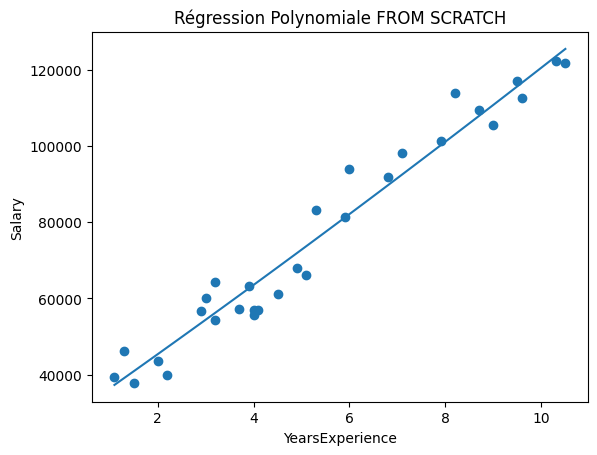

In [10]:
# 8️⃣ Visualisation (courbe lisse)
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1,1)
X_range_poly = polynomial_features(X_range, degree)

plt.scatter(X, y)
plt.plot(X_range, X_range_poly.dot(theta))
plt.xlabel('YearsExperience')
plt.ylabel('Salary')
plt.title('Régression Polynomiale FROM SCRATCH')
plt.show()

In [11]:

# 9️⃣ Nouvelle prédiction
NewData = np.array([[5],[4]])
NewData_poly = polynomial_features(NewData, degree)

y_new = NewData_poly.dot(theta)
print("Nouvelles prédictions :", y_new)

Nouvelles prédictions : [72796.93530558 63553.03842097]
